In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
# Create session
session = cm.Session(
    name = 'mini',
    data_path = 'data'
)

session.add_scenario(
    name='none',
    years=[0]
)

A scenario with the name 'none' already exists use .update_scenario() or .remove_scenario() instead.


In [99]:
%%time
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions, sub_systems = {})

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

CPU times: total: 172 ms
Wall time: 191 ms


In [126]:
%%time
cm.ParameterRetriever.update_all_parameter_values()
cm.ParameterRetriever.update_relation_tables()

regions.calculate(verbose=True)
demand.calculate(verbose=True)
crops.calculate(verbose=True)
for h in herds:
    h.calculate(verbose=True)
feed_mgmt.calculate(verbose=True)

geodist.make(use_cons=[1,2,3,5,6,7], verbose=True)
geodist.solve(verbose=True)

session.store(
    'none', '0',
    demand, regions, crops, herds, geodist
)

[15:10:19][Regions] Getting initial crop areas and animal numbers (x0) ... 0.0s
[15:10:19][Regions] Getting climate and soil attributes ... 0.0s
[15:10:19][Regions] Calculating maximum land use ... 0.0s
[15:10:19][Regions] Done! Elapsed time: 0 sec
[15:10:19][DemandAndConversions] Calculating food demand ... 0.1s
[15:10:19][DemandAndConversions] Resolving recipies for compound foods ... 0.0s
[15:10:19][DemandAndConversions] Calculating waste ... 0.0s
[15:10:19][DemandAndConversions] Calculating product demand and generated by-products... 0.2s
[15:10:19][DemandAndConversions] Done! Elapsed time: 0 sec
[15:10:19][CropProduction] Calculating harvest ... 0.0s
[15:10:19][CropProduction] Calculating production ... 0.0s
[15:10:19][CropProduction] Calculating crop residues ... 0.0s
[15:10:20][CropProduction] Calculating seed demand ... 0.0s
[15:10:20][CropProduction] Done! Elapsed time: 0 sec
[15:10:20][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ... 0.3s
[15:10:

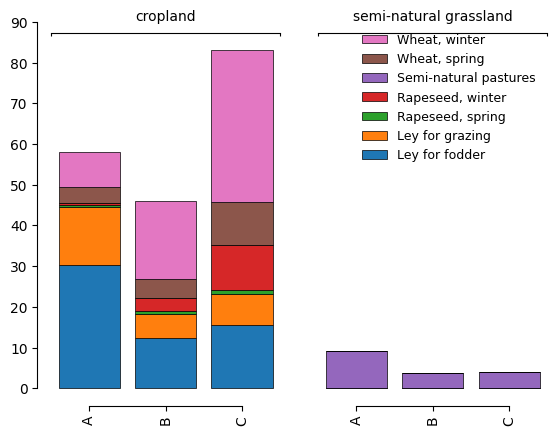

In [128]:
cm.plot.bar(
    session.get_attr('c','area',{'crop':['land_use',None],'region':None}).iloc[0].unstack('crop'),
    group_levels='land_use'
)
plt.show()

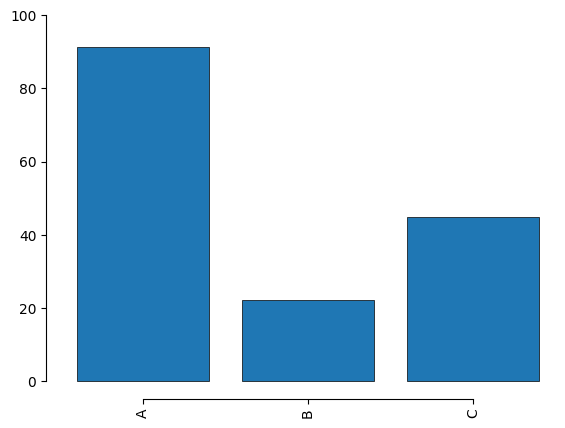

In [108]:
cm.plot.bar(
    session.get_attr('a','heads',['region','species']).iloc[0].unstack('species')
)
plt.show()

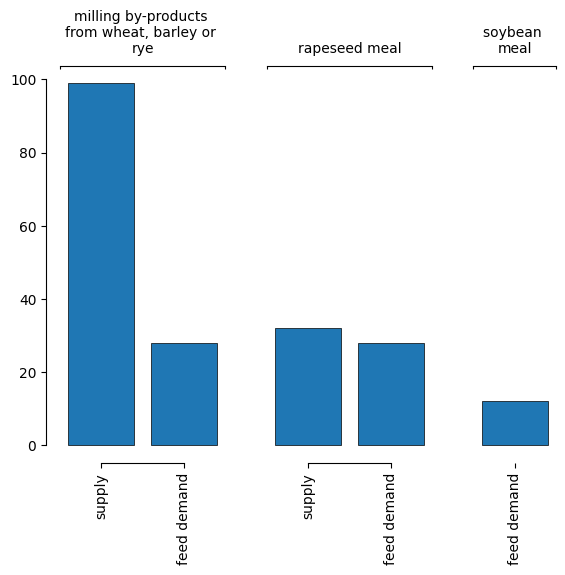

In [148]:
d = pd.concat([
    session.get_attr('d','by_products','by_prod').iloc[0].rename('supply'),
    session.get_attr('a','feed.by_product_demand','by_prod').iloc[0].rename('feed demand')
], axis=1).stack()/1000

cm.plot.bar(d, group_levels=0)
plt.show()